# 01 - Preparação dos Dados: 140k Real and Fake Faces

Este notebook cobre:
1. Download do dataset via Kaggle API.
2. Verificação da estrutura e contagem de imagens.
3. Visualização de amostras.
4. Definição dos transforms (com data augmentation no treino).
5. Criação dos DataLoaders para treino, validação e teste.

In [16]:
import subprocess
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
PROJECT_ROOT  = Path.cwd().resolve().parent
_data_root_file = PROJECT_ROOT / "data_root.env"
DATA_ROOT     = Path(_data_root_file.read_text().strip()) if _data_root_file.exists() else PROJECT_ROOT / "data"
DATASET_DIR   = DATA_ROOT / "raw" / "140k_faces"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
FIGURES_DIR   = PROJECT_ROOT / "reports" / "figures"
KAGGLE_DATASET = "xhlulu/140k-real-and-fake-faces"
IMAGE_SIZE    = 224
BATCH_SIZE    = 32
NUM_WORKERS   = 4

for folder in [DATASET_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Raiz do projeto:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Dataset em:", DATASET_DIR)

## 1. Download do Dataset

Requer a Kaggle API configurada. Coloque o arquivo `kaggle.json` em `~/.kaggle/` antes de executar.

Para obter o `kaggle.json`: Kaggle → Account → API → Create New Token.

In [18]:
zip_path = DATASET_DIR / "140k-real-and-fake-faces.zip"
data_path = DATASET_DIR / "real_vs_fake" / "real-vs-fake"

already_extracted = data_path.exists() and any(data_path.rglob("*.jpg"))

if already_extracted:
    print("Dataset já extraído em:", data_path)
else:
    if not zip_path.exists():
        print("Baixando dataset...")
        subprocess.run(
            [sys.executable, "-m", "kaggle", "datasets", "download",
             "-d", KAGGLE_DATASET, "-p", str(DATASET_DIR)],
            check=True
        )
    print("Extraindo...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATASET_DIR)
    print("Concluído:", data_path)

Dataset já extraído em: C:\Users\pedro\OneDrive\Documents\PUC\Projeto 5\Projeto-5-Redes-Neurais\data\raw\140k_faces\real_vs_fake\real-vs-fake


## 2. Verificação da Estrutura

In [19]:
splits = ["train", "valid", "test"]
classes = ["real", "fake"]

rows = []
for split in splits:
    for cls in classes:
        folder = data_path / split / cls
        count = len(list(folder.glob("*.jpg")))
        rows.append({"split": split, "classe": cls, "imagens": count})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
print("\nTotal:", summary_df["imagens"].sum())

split classe  imagens
train   real    50000
train   fake    50000
valid   real    10000
valid   fake    10000
 test   real    10000
 test   fake    10000

Total: 140000


## 3. Visualização de Amostras

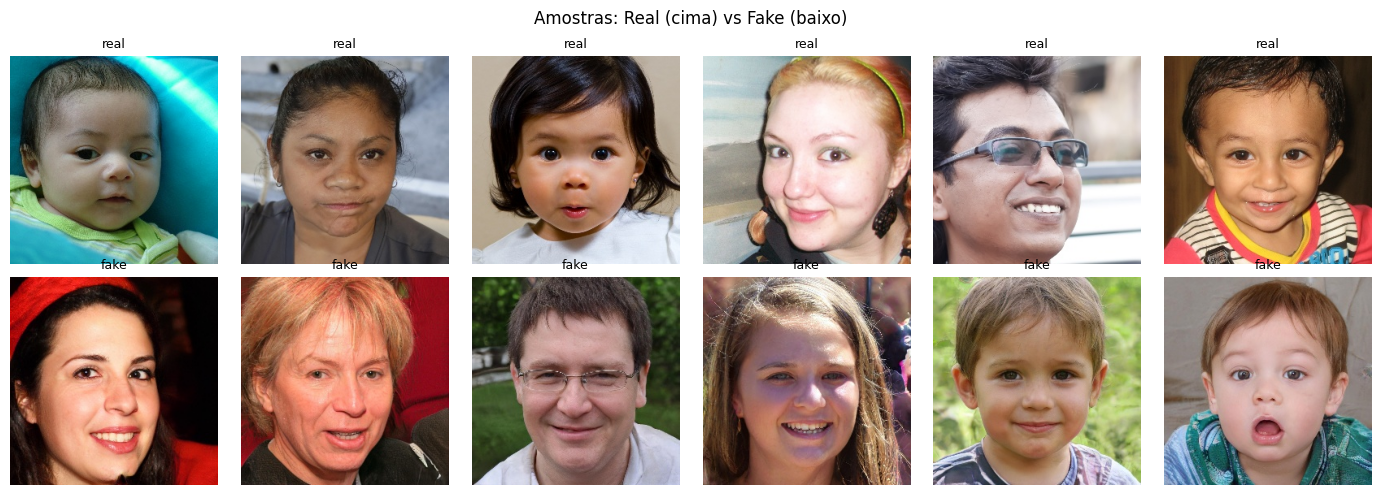

In [20]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for row_idx, cls in enumerate(classes):
    images = sorted((data_path / "train" / cls).glob("*.jpg"))[:6]
    for col_idx, img_path in enumerate(images):
        axes[row_idx, col_idx].imshow(Image.open(img_path))
        axes[row_idx, col_idx].set_title(cls, fontsize=9)
        axes[row_idx, col_idx].axis("off")

plt.suptitle("Amostras: Real (cima) vs Fake (baixo)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "amostras_140k.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Transforms

Treino recebe data augmentation (flip horizontal, rotação leve, variação de cor) para melhorar a generalização. Validação e teste apenas redimensionam e normalizam.

In [21]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms definidos.")

Transforms definidos.


## 5. Datasets e DataLoaders

In [22]:
train_dataset = datasets.ImageFolder(data_path / "train", transform=train_transform)
valid_dataset = datasets.ImageFolder(data_path / "valid", transform=eval_transform)
test_dataset  = datasets.ImageFolder(data_path / "test",  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Classes:", train_dataset.classes)
print(f"Treino:    {len(train_dataset):>6} imagens | {len(train_loader):>4} batches")
print(f"Validação: {len(valid_dataset):>6} imagens | {len(valid_loader):>4} batches")
print(f"Teste:     {len(test_dataset):>6} imagens | {len(test_loader):>4} batches")

Classes: ['fake', 'real']
Treino:    100000 imagens | 3125 batches
Validação:  20000 imagens |  625 batches
Teste:      20000 imagens |  625 batches


## 6. Verificação de um Batch

In [23]:
images, labels = next(iter(train_loader))
print("Shape do batch de imagens:", images.shape)
print("Shape dos labels:", labels.shape)
print("Labels únicos no batch:", labels.unique().tolist())

Shape do batch de imagens: torch.Size([32, 3, 224, 224])
Shape dos labels: torch.Size([32])
Labels únicos no batch: [0, 1]
